In [1]:
from tvb.simulator.lab import *
from tvb.simulator import monitors
import numpy as np
from tvb.simulator.backend.dopa_backend import DOPABackend
from tvb.simulator.backend.izimf_backend import IZIMFBackend
from tvb.simulator.backend.nb_mpr import NbMPRBackend
import matplotlib.pyplot as plt

/home/danie/tvb/tvb-root/tvb_library/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


Simulation of one excitatory node 

In [2]:
# load connectivities
conn_excitator=np.array([[0.0]])
conn_dopamine=np.array([[0.0]])
conn_inhibitor=np.array([[0.0]])


conn = connectivity.Connectivity()
conn.region_labels = np.array(["L.BSTS"])
conn.centres = np.zeros((3,1)).astype('float64') 
conn.weights = conn_excitator # inhibitory and dopamine connectivity has to be introduced later (multiple connectivites not implemented in TVB)
conn.tract_lengths = (conn_excitator*.0+0.00).astype('i') # another trick, we won't be using delays
conn.configure()



In [3]:

g_dopa, g_excit, g_inhib = np.array([0]), 1.0, np.array([0])

nsigma = 0.000
n_nodes = 1
r0, V0, u0, sa0, sg0, Dp0, Md0 = 0.0, -60.0, 0.0, 0.0, 0.0, 0.0, 0.0 
init_cond = np.array([r0, V0, u0, sa0, sg0, Dp0, Md0])
initial_cond = np.repeat(init_cond, n_nodes).reshape((1, 7, 1, 1))


In [4]:
model = models.IziMF(C=np.array([100.0]), k=np.array([0.7]), Delta=np.array([0.5]), v_r=np.array([-60.0]), v_t=np.array([-40.0]), ga=np.array([1.0]), E_r=np.array([0.0]), I=np.array([50.0]), 
     kappa=np.array([100.0]), tausa=np.array([6.0]), sja=np.array([15.0]))

In [5]:
model??

Type:           IziMF
String form:   
IziMF (
  C ....................... 100.0
  Delta ................... 0.5
  E_r ..................... 0.0
  I ....................... 50.0
  Km ...................... 150.0
  Rd ...................... 1.0
  Sd ...................... -1.0
  Type .................... IziMF
  Vmax .................... 1300.0
  Z ....................... 1.0
  a ....................... 0.03
  b ....................... -2.0
  coupling_terms .......... ['Coupling_Term_r', 'Coupling_Term_v', 'Coupling_Term_u', 'Coupling_Term_sa', 'Coupling_term_sg', 'Coupling_term_Dp', 'Coupling_term_Md']
  eta ..................... 10.0
  ga ...................... 1.0
  gg ...................... 15.0
  gid ..................... UUID('6009aed7-750a-4553-85d5-1bcf669a0251')
  k ....................... 0.7
  kappa ................... 100.0
  parameter_names ......... ['Delta', 'eta', 'C', 'k', 'v_r', 'v_t', 'ga', 'gg', 'E_r', 'b', 'a', 'kappa', 'tausa', 'tausg', 'sja', 'sjg', 'I', 'Vmax', 'K

In [6]:
def configure_sim(g_excit=None, nsigma=0.0, conn=conn):
    sim = simulator.Simulator(
    model=model,
    connectivity=conn,
    coupling=coupling.Linear(
        a=np.array([g_excit])
    ),
    conduction_speed=1.,
            integrator=integrators.HeunStochastic(
            dt=0.01,
            noise=noise.Additive(
                nsig=np.array(
                    [nsigma,nsigma*10,nsigma/5,nsigma/10,nsigma/2,nsigma*10, nsigma*10]
                ), 
                noise_seed=42)
        ),
    monitors=[monitors.Raw()],
    initial_conditions=init_cond.reshape(1,7,1,1)
    ).configure()
    return sim

In [7]:
sim = configure_sim(g_excit=1.0, nsigma=0.00, conn=conn)

In [8]:
izimf_backed = IZIMFBackend()

In [9]:
(t, tavg), c = izimf_backed.run_sim(sim, conn_inhibitor, conn_dopamine, g_inhib, g_dopa, simulation_length=2500)


(array([0.5]), array([10.]), array([100.]), array([0.7]), array([-60.]), array([-40.]), array([1.]), array([15.]), array([0.]), array([-2.]), array([0.03]), array([100.]), array([6.]), array([6.]), array([15.]), array([15.]), array([50.]), array([1300.]), array([150.]), array([500.]), array([1.]), array([-1.]), array([1.]), array([500.]))


/home/danie/tvb/tvb-root/tvb_library/tvb/simulator/backend/izimf_backend.py:136: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  coupling = cx(X, connectivities, g_i, g_e, g_d)


In [10]:
tavg[0].shape


(7, 1)

In [11]:
arr = np.array(tavg)

In [12]:
arr.shape

(250000, 7, 1)

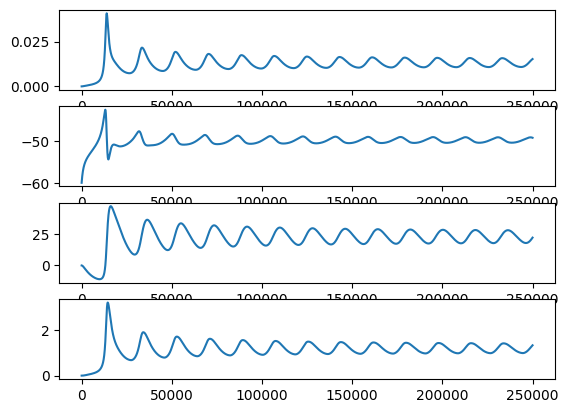

In [13]:
t = np.arange(0, 25000, 0.01)
fig, axes = plt.subplots(4,1)
for i in range(4):
    axes[i].plot(arr[:,i,:])   
    

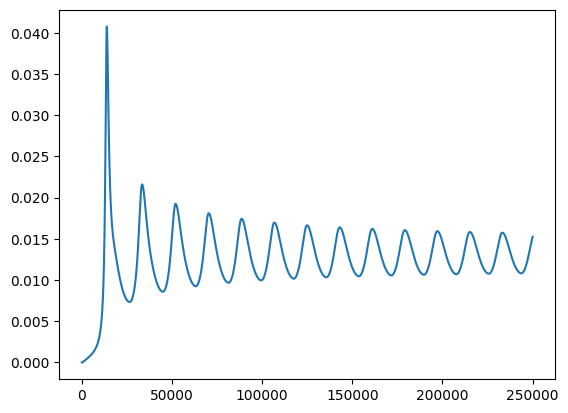

In [14]:

axes[i]=plt.plot(arr[:,0,:])

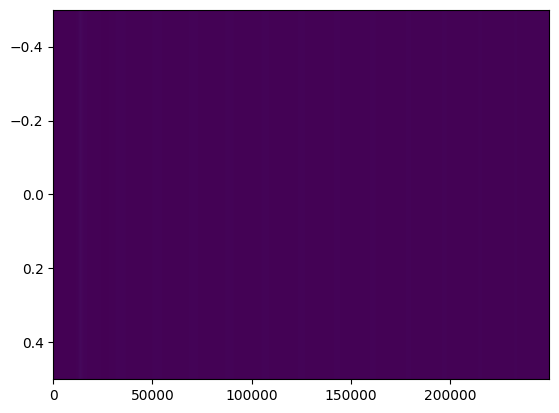

In [15]:
plt.imshow(tavg[:,0,:].T, aspect='auto', vmax=2)